In [ ]:
# Initialize Otter
import otter
grader = otter.Notebook("MRSA Data Analysis.ipynb")

# MRSA Data Analysis
### Professor Polly Parks

**Estimated Time**: 30-40 minutes <br>
**Databook created by**: Rucha Kelkar, Harry Li, Elias Saravia, Ariana Ghimire

Hi everyone! My name is Ariana, and I’m part of a team at UC Berkeley that builds interactive data science notebooks for community college students. Our goal is to make data science more accessible by connecting it with real-world topics across different fields—like biology, public health, economics, and ethnic studies. By combining data analysis with domain knowledge, we hope to show how computational tools can help answer meaningful questions.

### About This Notebook
Today we will be examining a dataset (a table of data) and several graphs related to Methicillin-resistant *Staphylococcus aureus* (MRSA), a bacterial infection that can cause serious illness. In this notebook, you’ll analyze patterns in the data and use your knowledge of immunity and infectious disease to draw conclusions about how MRSA spreads and affects populations.

Because this version of the notebook is designed for students who already have some programming experience, we’ll also use this as an opportunity to connect basic coding and data skills to clinical questions. You’ll work with Jupyter Notebooks (the platform you are currently using) and Python (a programming language) to explore the dataset, interpret visualizations, and practice thinking like both a clinician and a data scientist.

While the notebook will briefly review key tools, it will also give you a bit more independence to explore the data and develop your own insights.

### Table of Contents
1. [Intro to Jupyter](#0) <br>
1. [Intro to MRSA](#2) <br>
1. [Intro to Dataset](#3) <br>
1. [Comparing Infection Rates Over Time](#4) <br>
1. [Comparing County Infection Rates with County Populations](#5) <br>
1. [Exploring Census Data by County, Year, and Race](#6)
1. [Simple MRSA Scenario Modeling with Widgets ](#7)
1. [Download PDF to sumbit work](#8)

# 1. Intro to Jupyter <a id='0'></a>

This webpage is a Jupyter Notebook. Jupyter Notebooks run on the Python coding language and provides an interactive interface for students. We will use this notebook to analyze a dataset on MRSA bloodstream infections in California hospitals. Jupyter Notebooks are composed of both regular text and code cells. Code cells have a gray background. In order to run a code cell, click the cell and press Shift + Enter while the cell is selected or hit the ▶| Run button in the toolbar at the top. You can also save your work using the button on the top left hand corner. In a Jupyter Notebook, the **kernel** is the background process that runs and remembers all the code you execute. If certain libraries are imported in a different order, it can affect how widgets and plots behave. You can also restart the kernel by clicking **Kernel → Restart Kernel** in the top right menu of the Jupyter Notebook.  

An example of a code cell is shown below. The contents of this cell set up the notebook by importing pre-written Python packages that we will be using to read in, clean, analyze, and model our data. Run it, and once it is done, you should see "Done!" printed underneath the cell. 

In [84]:
## DO NOT DELETE ANYTHING IN THIS CELL ##
%pip install otter-grader numpy pandas datascience matplotlib ipywidgets notebook
# import utilities
import os
from pathlib import Path

from otter import Notebook
import numpy as np
import pandas as pd
from datascience import *
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Make relative data-file paths work even if Jupyter starts in the project root.
for candidate_dir in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate_dir / "mrsa_merged.csv").exists():
        os.chdir(candidate_dir)
        break
else:
    raise FileNotFoundError(
        "Could not locate 'mrsa_merged.csv'. Open the notebook from the project folder or the 'mrsa' folder."
    )

widgets.IntSlider()
print("Done!")



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Done!


<br><br>
### 1.1 Common errors and how to fix them

##### Accidentally deleted something in a cell? 
Double click on that cell and press Ctrl+Z or Command+Z until you recover the deleted information. Otherwise, ask your GSI for help. 

##### Getting a really long error message? 
This could be a result of deleting code somewhere in the notebook in a code cell. If you remember which cell you deleted code from, double click on that cell and press Ctrl+Z or Command+Z until the code is as it was originally. Otherwise, raise your hand and ask for help from your GSI. 

##### Getting the error 'data_frame' not present? 
Make sure you have all of the relevant data files in the same folder as this notebook (mrsa_merged.csv, infec_pop_merge.csv, mrsa_2013.csv, mrsa-in-hospitals-2013.csv, census_bonus.csv) and that widgets.py is in the same folder. 

##### Something is running for too long? 
Try restarting the kernel. Sometimes Jupyter might be overloaded with the simplest of commands. Don't worry, just save your work and restart the kernel. 

##### Getting multiple plots in the widgets below?
This happened because you ran the line `from datascience import *`  before working with the plot widgets. Try restarting the kernel and making sure you finish your work with the plot widgets BEFORE running the code cell with the aforementioned line.

---

# 2. Intro to MRSA <a id='2'></a>


MRSA, or methicillin resistant S. auereus, is one example of a bacteria that is highly resistant to antibiotics. It is usually a hospital acquired infection though it can also be spread through the community. A review of 15 studies showed that 13-74% of all *S. aureus* infections are MRSA. For future nurses, this matters because MRSA infections change the kinds of precautions you take, the antibiotics that are ordered, and how closely you monitor patients for complications. Managing this infection requires careful indentification of the MRSA strain and source of infection, proper choice of antibiotics, and robust prevention strategies. Active surveillance of personnel and disinfection of healthcare equipment and rooms is critical for prevention. For more information on MRSA, refer back to you professor's lecture slides on this topic.

<!-- BEGIN QUESTION -->

<!-- BEGIN QUESTION -->

### Discussion Question 1: 
**From what you know about MRSA and our class content, where do you think the majority of MRSA cases are located in California (urban counties vs. rural counties)?**

**How could a difference in population density affect the total number of MRSA infections?**

**What possible downstream connections can be made in relation to the workload for nurses and other healthcare staff?**

_Type your answer here, replacing this text._

REPLACE THIS TEXT WITH YOUR RESPONSE
<br> [Note: double click on the cell, type in your response, and run the cell to save your work]

<!-- END QUESTION -->

---

# 3. Intro to Data <a id='3'></a>

### 3.1 Reading in Data Sets

We will be analyzing is the Methicillin-resistant Staphylococcus aureus (MRSA) bloodstream infections (BSI) in California Hospitals data from the [California Health and Human Services Agency](https://data.chhs.ca.gov/dataset/methicillin-resistant-staphylococcus-aureus-mrsa-bloodstream-infections-bsi-in-california-hospitals). 

> California Health and Safety Code section 1288.55(a)(1) requires general acute care hospitals to report all cases of Methicillin-resistant Staphylococcus aureus (MRSA) bloodstream infections (BSI) identified in their facilities to the California Department of Public Health (CDPH). MRSA BSI data are submitted by hospitals to the Centers for Disease Control and Prevention National Healthcare Safety Network (NHSN). CDPH downloads California hospital MRSA BSI data from NHSN and analyzes the data to describe prevention progress in an annual public report of healthcare-associated infections. CDPH publishes annual MRSA BSI data reported by each California hospital in the datasets below.

Run the code cell below to load the data that we will be using for analysis.

In [85]:
# This cell will read in the necessary data sets. Run it and take a look at the dataframes below!
mrsa_merged = pd.read_csv('mrsa_merged.csv') #merged mrsa data
infec_pop_merge = pd.read_csv('infec_pop_merge.csv') #combined mrsa and population data

print("Done!")

Done!


### 3.2 Understanding the Data

Let's visualize the raw data of MRSA Reports in 2013. Data is usually recorded in a dataset (or table) format with rows and columns. Each row represents a distinct observation and each column represents a feature/variable. Run the code cell below to see the dataset. You can scroll horizontally to see all of the columns that are included.

In [86]:
mrsa_2013_raw = pd.read_csv('mrsa-in-hospitals-2013.csv') #raw data
mrsa_2013_raw.head()

,Year,State,HAI,Facility_Name1,Facility_Name2,Facility_Name3,FACID1,FACID2,FACID3,County,Infection_Count,Patient_Days,SIR,SIR_95%_CI_Lower_Limit,SIR_95%_CI_Upper_Limit,Comparison,Notes
0,2013,California,Methicillin-Resistant Staphylococcus aureus Bl...,"Adventist Medical Center, Hanford",Adventist Medical Center-Selma,.,40000122,630012960,.,Kings-Fresno,2.0,42875.0,0.76,0.13,2.50,No Different,† See Data Dictionary
1,2013,California,Methicillin-Resistant Staphylococcus aureus Bl...,"Adventist Medical Center, Reedley",.,.,40000124,.,.,Fresno,0.0,5970.0,NaN,NaN,NaN,.,NaN
2,2013,California,Methicillin-Resistant Staphylococcus aureus Bl...,"AHMC Anaheim Regional Medical Center, Anaheim",.,.,60000002,.,.,Orange,3.0,51929.0,1.15,0.29,3.13,No Different,NaN
3,2013,California,Methicillin-Resistant Staphylococcus aureus Bl...,"Alameda County Medical Center, Oakland","Alameda County Medical Center-Fairmont Campus,...",.,140000034,140000184,.,Alameda,7.0,55590.0,2.09,0.91,4.12,No Different,† See Data Dictionary
4,2013,California,Methicillin-Resistant Staphylococcus aureus Bl...,Alameda Hospital,.,.,140000011,.,.,Alameda,0.0,11520.0,0.00,0.00,2.88,No Different,NaN


Shown above are the first five rows of the the data table. As you can see, there are a lot of columns as well as a lot of missing information in some of the columns. We have cleaned the data for you by removing any unncessary features and renaming the columns to make their purpose more clear. Run the code cell below to see the cleaned data set from MRSA Reports in 2013 below. 

In [87]:
mrsa_2013 = pd.read_csv('mrsa_2013.csv') #cleaned data
mrsa_2013.head()

,Year,State,HAI,Facility1,Facility1_ID,County,Infection_Count,Num_patients
0,2013,California,Methicillin-Resistant Staphylococcus aureus Bl...,"Adventist Medical Center, Reedley",40000124,Fresno,0.0,5970.0
1,2013,California,Methicillin-Resistant Staphylococcus aureus Bl...,"AHMC Anaheim Regional Medical Center, Anaheim",60000002,Orange,3.0,51929.0
2,2013,California,Methicillin-Resistant Staphylococcus aureus Bl...,"Alameda County Medical Center, Oakland",140000034,Alameda,7.0,55590.0
3,2013,California,Methicillin-Resistant Staphylococcus aureus Bl...,Alameda Hospital,140000011,Alameda,0.0,11520.0
4,2013,California,Methicillin-Resistant Staphylococcus aureus Bl...,Alhambra Hospital Medical Center,930000005,Los Angeles,0.0,19433.0


---

### 3.3 Breaking down the table

#### 3.3.1 Rows

Let's take a look at the first row of the dataset for MRSA Reports in 2013. 

In [88]:
mrsa_2013.take([0])

,Year,State,HAI,Facility1,Facility1_ID,County,Infection_Count,Num_patients
0,2013,California,Methicillin-Resistant Staphylococcus aureus Bl...,"Adventist Medical Center, Reedley",40000124,Fresno,0.0,5970.0


This particular row in our data represents a 2013 report representing the number of MRSA infections recorded in the Adventist Medical Center, Reedley in the Fresno County.

Therefore, in general, every row in our dataset represents a distinct MRSA report from a California hospital in 2013.

Try analyzing another row, just change the number `0` in the above code cell to see that numbered row. Since there are only 352 rows in our table, be sure your number is less than 352. 

#### 3.3.2. Columns
Run the code cell below to see the list of the columns in our dataset.

In [89]:
mrsa_2013.columns.tolist()

['Year',
 'State',
 'HAI',
 'Facility1',
 'Facility1_ID',
 'County',
 'Infection_Count',
 'Num_patients']

<!-- BEGIN QUESTION -->

Take a look at the columns names of the table listed above. Most of the columns should be pretty self-explanatory. For those that aren't, 
- **HAI:** Hospital Acquired Infection. This refers to MRSA infections in hospital patients only. 
- **Facility1:** the name of the specific medical center/hospital.
- **Facility1_ID:** a unique number identifier for the medical facility.

### Discussion Question 2:
**Of the questions we asked about MRSA, which are actually answerable given this dataset? Which questions could be answerable with a different dataset? And which would be hard to answer with the data we gave you?**

_Type your answer here, replacing this text._

REPLACE THIS TEXT WITH YOUR RESPONSE
<br> [Note: double click on the cell, type in your response, and run the cell to save your work]

<!-- END QUESTION -->

---

# 4. Comparing Infection Rates Over Time <a id='4'></a>

Previously, we were looking at the MRSA infections in hospitals in 2013. Now, we combined multiple datasets for MRSA Reports from 2013 - 2018. Our goal in analyzing this dataset is to see how the infection rates have changed over time across counties.

Use the plot widget to answer the discussion question below. Run the code cell below and toggle through the drop-down menu to look at infection counts for different counties.

In [90]:
from widgets import infection_rates_per_county
%matplotlib inline
infection_rates_per_county()

interactive(children=(Dropdown(description='County', options=('Fresno', 'Orange', 'Alameda', 'Los Angeles', 'S…

<!-- BEGIN QUESTION -->

### Discussion Question 3:
**Choose one urban county (e.g. Los Angeles) and one rural county (e.g. Sonoma) to evaluate. What trends can you identify? What outliers do you see? Make a general statement on how MRSA infections have changed over time in these two counties.**


_Type your answer here, replacing this text._

REPLACE THIS TEXT WITH YOUR RESPONSE
<br> [Note: double click on the cell, type in your response, and run the cell to save your work]

<!-- END QUESTION -->

---

# 5. Comparing County Infection Rates with County Populations <a id='5'></a>


### 5.1 Infection rate by county per year

We can use the same data to compare the infection rates based on the population within a county. A question we can ask is: What is the trend over the years of total population against infection counts? 

The following code cell displays a widget that plots a regression (best fit) line over these two variables. See if you can catch an interesting trend.

In [91]:
from widgets import population_v_infection_by_county
population_v_infection_by_county()

interactive(children=(Dropdown(description='County', options=('Alameda', 'Amador', 'Butte', 'Calaveras', 'Colu…

<!-- BEGIN QUESTION -->

### Discussion Question 4: 

**Look at the same two urban and rural counties that you chose for the previous question. What information can you draw from the above graph for those two counties?** 

_Type your answer here, replacing this text._

REPLACE THIS TEXT WITH YOUR RESPONSE
<br> [Note: double click on the cell, type in your response, and run the cell to save your work]

<!-- END QUESTION -->

---

### 5.2 Infection rate across counties by year 

The last portion of our analysis will be to look at infection counts across all counties each year. We calculate a "best fit" regression line to estimate the rate of infection. 

Run the code cell below to load the widget. Feel free to select different years to see the change in slopes.

In [92]:
from widgets import population_vs_infection_by_year
population_vs_infection_by_year()

interactive(children=(Dropdown(description='Year', options=(2013, 2014, 2015, 2016, 2017, 2018), value=2013), …

<!-- BEGIN QUESTION -->

### Discussion Question 5: 

**Select different years in the graph above. What do you notice about the slope across different years? What information can you draw from the graph above?** 

_Type your answer here, replacing this text._

REPLACE THIS TEXT WITH YOUR RESPONSE
<br> [Note: double click on the cell, type in your response, and run the cell to save your work]

<!-- END QUESTION -->

---

### 5.3 California Counties Colored by Infection Rate (number of infections/population)

We can also use maps to gain more insight from the data. 

A choropleth map (from Greek χῶρος "area/region" and πλῆθος "multitude") is a type of thematic map in which areas are shaded or patterned in proportion to a statistical variable that represents an aggregate summary of a geographic characteristic within each area, such as population density or per-capita income.

Below is a a **chloropleth map**, which is similar to a heat map where color schemes in areas communicate high values with bright colors and low values with darker colors. For example, a [weather map](https://www.google.com/search?q=weather+map&hl=en&source=lnms&tbm=isch&sa=X&ved=2ahUKEwjdhcDEhbLoAhWM4J4KHX2aCLoQ_AUoAXoECA0QAw&biw=1440&bih=821#imgrc=OmR67PwUq48WEM) shows high temperature in red and colder temperature in blue. This map shows each California County and the rate of infection per unit of population (100,000 people). The darker red the county, the higher its MRSA infection rate is. The colorbar on the right side of the map shows the range of infection rates. Take a look at the map below and use it to answer the discussion question below. 

<img src="ca_map.png" style="width: 1200px;"/>

<!-- BEGIN QUESTION -->

### Discussion Question 6:
**Having looked at the chloropleth map of California counties above, what trends/outliers do you see? Find your two chosen urban and rural counties from previous questions. Are the MRSA infection rates (denoted by color) consistent with what you originally thought? What would you say overall about the relationship between infection rates and population?**

_Type your answer here, replacing this text._

REPLACE THIS TEXT WITH YOUR RESPONSE
<br> [Note: double click on the cell, type in your response, and run the cell to save your work]

<!-- END QUESTION -->

---

# 6. Exploring Census Data by County, Year, and Race <a id='6'></a>

Our datasets also include **California Census population data**. Each row contains:
- The **year** and **county**.
- The **total population**.
- Breakdowns of the population by **race** and **sex**.

In this section, you will:

1. Review how a **group by** operation works.
2. Look at a table thats grouped by year and county.
3. Use simple code (no widgets) to:
   - Focus on one county across years.
   - Make at least one plot that compares total population or a specific race group over time.
   - Interpret what you see from a public‑health / nursing perspective.

### 6.1 Quick review: what does **group by** mean?

A **group by** operation answers questions like:

- “What is the total MRSA infection count **per year**?”
- “What is the total population **per county**?”

In plain language, you:

1. **Choose a column (or columns) to group by** (for example, `Year`).
2. **Combine all rows that share the same values** in those columns.
3. **Apply a summary function** (often `sum`, `mean`, or `count`) to the numeric columns.

In the code below, use the group operation to group by 'Year' and 'County' and apply the function 'sum'. Once you have gone through this section once, feel free to mix up vairble/operation. 

<details>
<summary><strong>HINT:</strong></summary>

```python
census_bonus = Table.read_table('census_bonus.csv').group(['Year','County'],sum)



In [93]:
census_bonus = Table.read_table('census_bonus.csv').group([...],...)
census_bonus.show(5)

TypeError: column functions must be callable

### 6.2 Guided exploration with `census_bonus`

We’ll walk through some specific steps. 

#### Step 1 – Pick one county and look at its rows

Use the code cell below to filter to a single county (for example, `Alameda County`) across years and display the first few rows.


In [ ]:
# Step 1: filter to a single county (you can change the name)
county_name = 'Alameda County'  # note: match the exact spelling from the table
census_county = census_bonus.where('County', county_name)
census_county.show(5)

NameError: name 'census_bonus' is not defined

#### Step 2 – Plot **total population** vs. year

Use the built‑in `Table.plot` method to make a simple line plot of total population over time for that county.


In [ ]:
# Step 2: plot total population vs year for that county
%matplotlib inline
census_county.plot('Year', 'Total_Population sum')

NameError: name 'census_county' is not defined

### Step 3 – Focus on one race group

Choose one of the race columns (for example, `Asian Male sum` + `Asian Female sum`) and make a plot that shows how that sub‑population changes over time. Fill in the ... to execute the code. 

Look back at the table to see column names that should fill in the '....'

If you are having trouble there is an example of what the code would look like for the Asian population if you click on 'HINT' below.

<details>
<summary><strong>HINT:</strong></summary>

```python
asian_total = census_county.select('Year', 'Asian Male sum', 'Asian Female sum')

asian_total = asian_total.with_column(
    'Asian total',
    asian_total.column('Asian Male sum') + asian_total.column('Asian Female sum')
)

asian_total.select('Year', 'Asian total').plot('Year')
plt.show()

In [ ]:
# Step 3: plot one race group vs year
race_total = census_county.select('Year', '....', '.....')
race_total = race_total.with_column(
    'race total',
    race_total.column('....') + race_total.column('...')
)

race_total.select('Year', 'race total').plot('Year')
plt.show()

NameError: name 'census_county' is not defined

---

### 6.3 Interactive: race totals by county and year

Use the widget below to compare **race total** (male + female) to each **individual** sex column over time. Choose **All counties (average)** to see the **average race total per year** (and average male / female) across California counties, or pick a single county to match the plots above.

In [ ]:
import importlib
import widgets

importlib.reload(widgets)
widgets.census_race_totals_widget()

interactive(children=(Dropdown(description='County', index=1, layout=Layout(width='420px'), options=('All coun…

### 6.4 Compare multiple whole-race groups

Each line is **one race total** (male + female combined), not separate sex columns. Use the **checkboxes** to select multiple races and overlay them on the same graph.

The graph also includes one extra dashed black line showing the **overall average across all races** for the selected county.

In [ ]:
import importlib
import widgets

importlib.reload(widgets)
widgets.census_race_multiselect_widget()

# 7. Simple MRSA Scenario Modeling with Widgets <a id='7'></a>

In the sections above, you worked with real MRSA data and interpreted several graphs. In this section, you will use a **simple mathematical model** to explore "what if" scenarios for MRSA bloodstream infections in a single county. This is **not** a predictive clinical tool; instead, it is a way for you to practice thinking about how infection counts might change over time and how nursing and public‑health interventions (like improved hand hygiene, isolation precautions, or antibiotic stewardship) could change those trends.

With the widget below, you will be able to change only three pieces of information:

- Starting number of MRSA cases in a single county.
- How fast cases change each month before an intervention (a positive percentage means cases are growing, a negative percentage means they are shrinking).
- The month when an intervention begins (for example, when a new infection‑control policy is put in place).

Behind the scenes, the model uses the **real MRSA dataset from earlier in the notebook** to estimate an average growth (or decline) rate *after* the intervention. In other words, you control the starting conditions and the pre‑intervention trend, and the model automatically connects your scenario to typical post‑intervention behavior seen in the data.

As you move the sliders, pay attention to **how quickly the curve grows or falls** and think about what that would mean for nurses, patients, and hospital capacity.

interactive(children=(IntSlider(value=20, description='Init cases', max=200, min=1), FloatSlider(value=5.0, de…

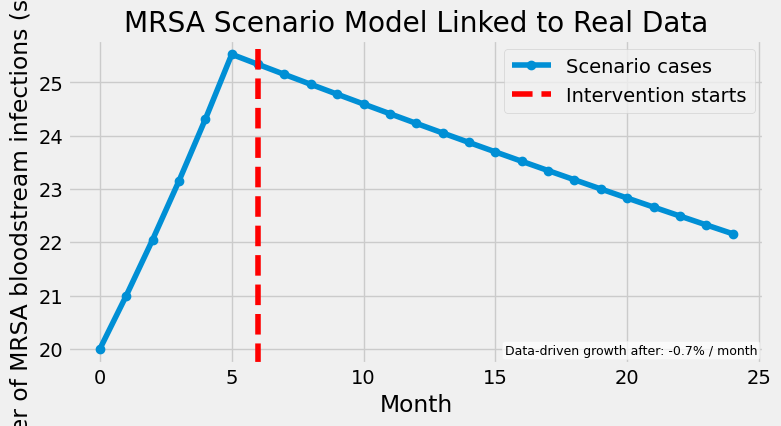

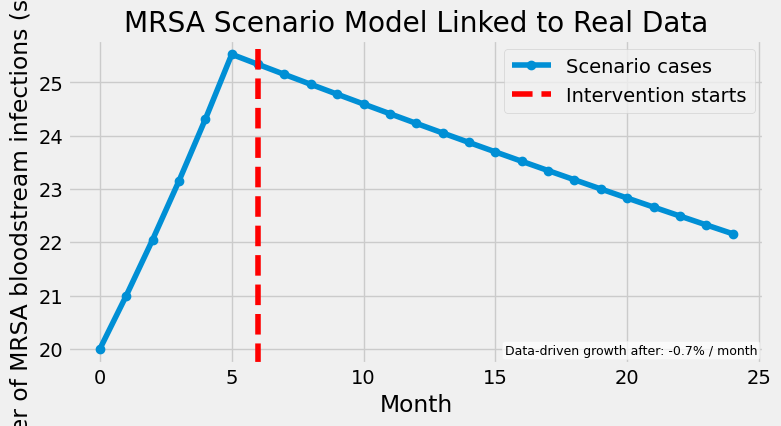

In [13]:
from widgets import mrsa_scenario_widget

mrsa_scenario_widget()

<!-- BEGIN QUESTION -->

### Discussion Question 7

Remember: in the widget above **you control only** the starting number of cases, the growth rate *before* intervention, and the month when intervention begins. The growth rate *after* intervention is automatically estimated from the real MRSA dataset.

Use the sliders to create **two different scenarios**:
1. **Scenario A – Later or weaker response**: choose a higher pre‑intervention growth rate and/or a later intervention month so that cases get quite high before the data‑driven post‑intervention trend can slow them down.
2. **Scenario B – Earlier or stronger response**: choose a lower pre‑intervention growth rate and/or an earlier intervention month so that the data‑driven post‑intervention trend has more time to reduce cases.

For each scenario, briefly describe:
- **What the curve looks like** (shape and steepness) before and after intervention.
- **How the workload and priorities for nurses might change** over the months shown (for example, staffing, isolation rooms, PPE use).
- **Which infection‑control actions and timing** (for example, isolation, hand hygiene campaigns, antibiotic stewardship, screening) could realistically produce the kind of pre‑intervention and post‑intervention behavior you see in the model.

<!-- END QUESTION -->



## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [ ]:
# Save your notebook first, then run this cell to export your submission.
grader.export(run_tests=True)